<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Predicción de Aterrizaje de la Primera Etapa del Falcon 9 de SpaceX**[cite: 4]


 ## Laboratorio Práctico: Completar el EDA con Visualización[cite: 4]


Tiempo estimado necesario: **70** minutos[cite: 4]


En esta asignación, predeciremos si la primera etapa del Falcon 9 aterrizará con éxito. SpaceX anuncia lanzamientos de cohetes Falcon 9 en su sitio web con un costo de 62 millones de dólares; otros proveedores cuestan más de 165 millones de dólares cada uno, gran parte de los ahorros se debe al hecho de que SpaceX puede reutilizar la primera etapa.[cite: 4]

En este laboratorio, realizará un Análisis Exploratorio de Datos e Ingeniería de Características.[cite: 4]


La primera etapa del Falcon 9 aterrizará con éxito[cite: 4]


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Varios ejemplos de un aterrizaje fallido se muestran aquí:[cite: 4]


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


La mayoría de los aterrizajes fallidos son planeados. Space X realiza un aterrizaje controlado en los océanos. [cite: 4]


  ## Objetivos[cite: 4]
Realizar un Análisis Exploratorio de Datos e Ingeniería de Características usando `Pandas` y `Matplotlib`[cite: 4]

- Análisis Exploratorio de Datos[cite: 4]
- Preparación de Datos e Ingeniería de Características [cite: 4]


----


Instale las bibliotecas a continuación[cite: 4]


In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

### Importar Bibliotecas y Definir Funciones Auxiliares[cite: 4]


Importaremos las siguientes bibliotecas para el laboratorio [cite: 4]



In [4]:
# Pandas es una biblioteca de software escrita para el lenguaje de programación Python para manipulación y análisis de datos.[cite: 4]
import pandas as pd
# NumPy es una biblioteca para el lenguaje de programación Python, que agrega soporte para grandes arreglos y matrices multidimensionales, junto con una gran colección de funciones matemáticas de alto nivel para operar en estos arreglos[cite: 4]
import numpy as np
# Matplotlib es una biblioteca de trazado (plotting) para python y pyplot nos da un marco de trazado similar a MatLab. Usaremos esto en nuestra función de trazado para graficar datos.[cite: 4]
import matplotlib.pyplot as plt
# Seaborn es una biblioteca de visualización de datos de Python basada en matplotlib. Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos[cite: 4]
import seaborn as sns

## Análisis Exploratorio de Datos [cite: 4]


Primero, leamos el conjunto de datos de SpaceX en un dataframe de Pandas e imprimamos su resumen[cite: 4]


In [5]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Si no pudo completar el laboratorio anterior correctamente, puede descomentar y cargar este csv[cite: 4]

# df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')[cite: 4]

df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


Primero, tratemos de ver cómo las variables `FlightNumber` (que indica los intentos continuos de lanzamiento) y `Payload` afectarían el resultado del lanzamiento.[cite: 4]

Podemos trazar el <code>FlightNumber</code> frente a <code>PayloadMass</code> y superponer el resultado del lanzamiento. Vemos que a medida que aumenta el número de vuelo, es más probable que la primera etapa aterrice con éxito. La masa de la carga útil también es importante; parece que cuanto más masiva es la carga útil, menos probable es que la primera etapa regrese.[cite: 4]


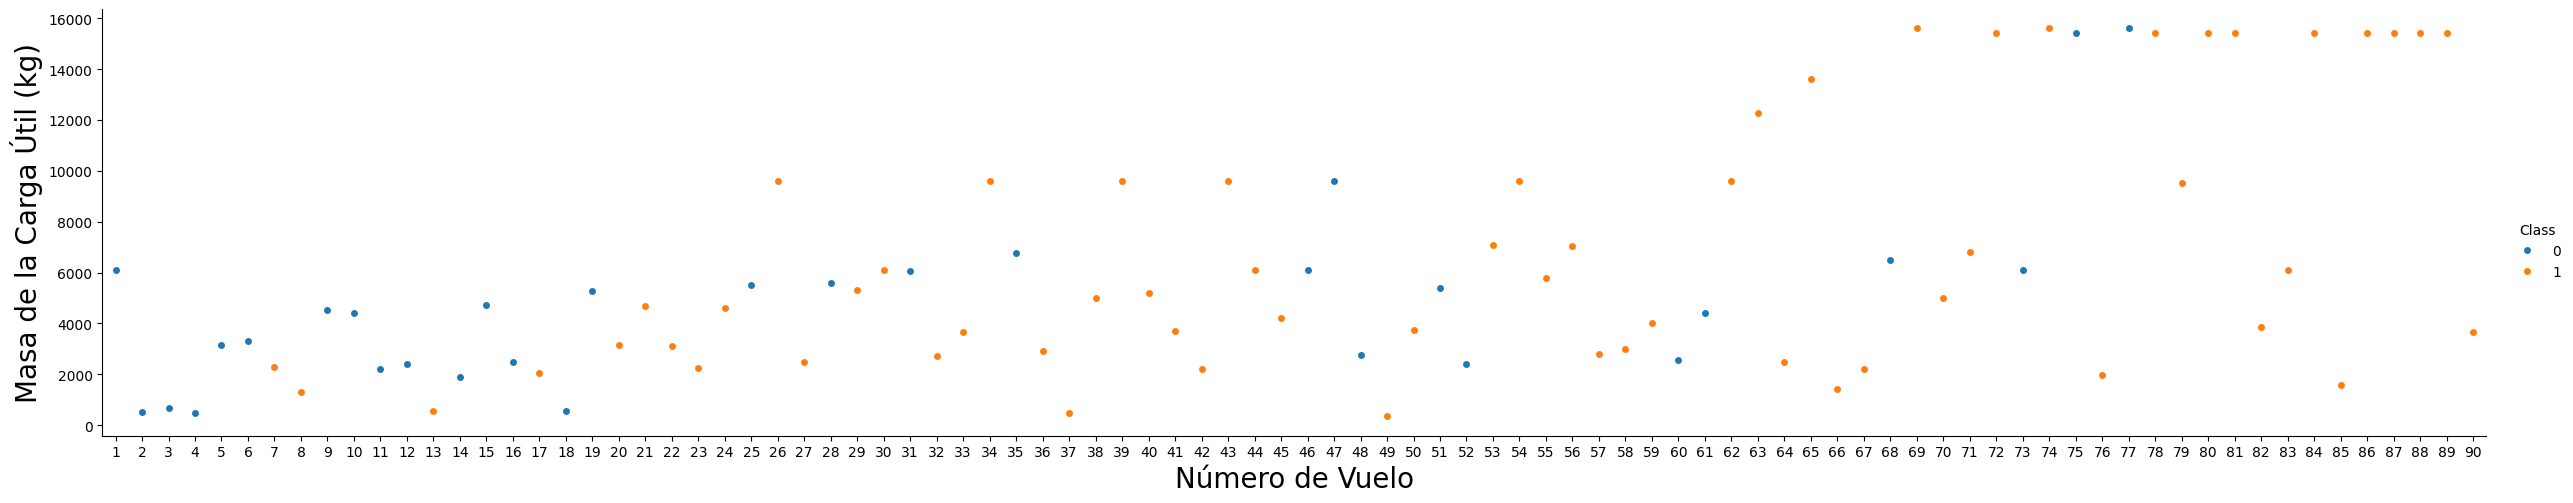

In [6]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Número de Vuelo",fontsize=20)
plt.ylabel("Masa de la Carga Útil (kg)",fontsize=20)
plt.show()

A continuación, profundicemos en cada sitio y visualicemos sus registros de lanzamiento detallados.[cite: 4]


### TAREA 1: Visualizar la relación entre el Número de Vuelo y el Sitio de Lanzamiento[cite: 4]


Use la función <code>catplot</code> para trazar <code>FlightNumber</code> vs <code>LaunchSite</code>, configure el parámetro <code>x</code> a <code>FlightNumber</code>, configure <code>y</code> a <code>LaunchSite</code> y configure el parámetro <code>hue</code> a <code>'Class'</code>[cite: 4]


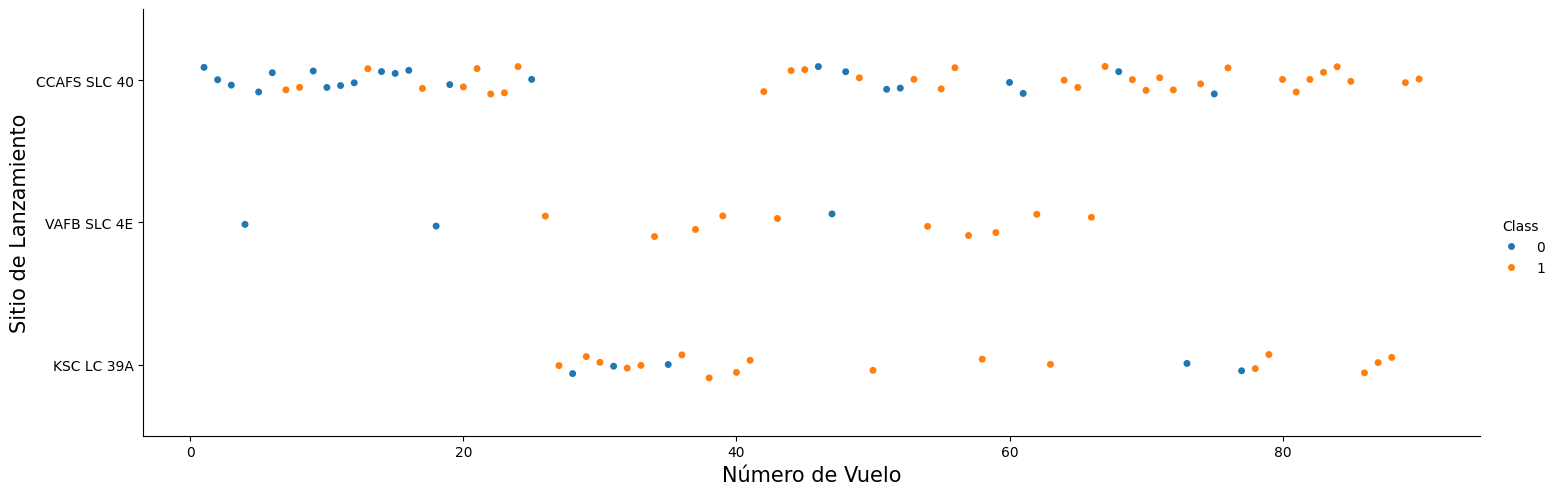

In [7]:
# Trace un gráfico de dispersión (scatter point chart) con el eje x como Número de Vuelo y el eje y como el sitio de lanzamiento, y hue (matiz) como el valor de la clase[cite: 4]
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect = 3)
plt.xlabel("Número de Vuelo",fontsize=15)
plt.ylabel("Sitio de Lanzamiento",fontsize=15)
plt.show()

Ahora intente explicar los patrones que encontró en los gráficos de dispersión de Número de Vuelo vs. Sitio de Lanzamiento.[cite: 4]


### TAREA 2: Visualizar la relación entre la Carga Útil y el Sitio de Lanzamiento[cite: 4]


También queremos observar si existe alguna relación entre los sitios de lanzamiento y su masa de carga útil.[cite: 4]


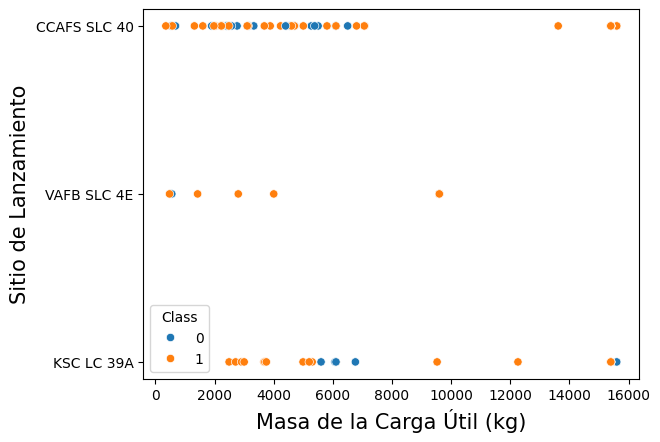

In [8]:
# Trace un gráfico de dispersión con el eje x como Masa de la Carga Útil (kg) y el eje y como el sitio de lanzamiento, y hue como el valor de la clase[cite: 4]
sns.scatterplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df)
plt.xlabel("Masa de la Carga Útil (kg)",fontsize=15)
plt.ylabel("Sitio de Lanzamiento",fontsize=15)
plt.show()

Ahora, si observa el gráfico de dispersión de Carga Útil Vs. Sitio de Lanzamiento, encontrará que para el sitio de lanzamiento VAFB-SLC no hay cohetes lanzados para una gran masa de carga útil (mayor a 10000).[cite: 4]


### TAREA  3: Visualizar la relación entre la tasa de éxito de cada tipo de órbita[cite: 4]


A continuación, queremos verificar visualmente si existe alguna relación entre la tasa de éxito y el tipo de órbita.[cite: 4]


Creemos un `gráfico de barras` para la tasa de éxito de cada órbita[cite: 4]


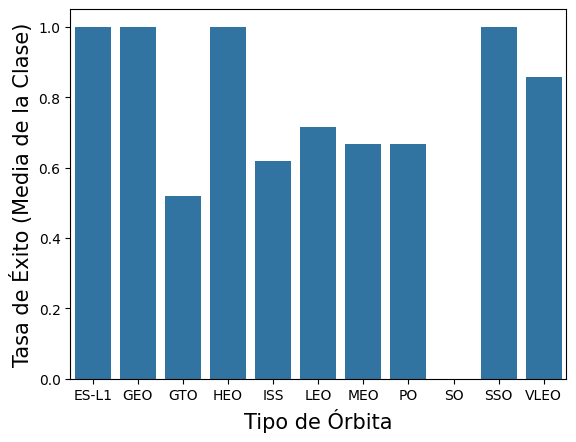

In [9]:
# PISTA: use el método groupby en la columna Orbit y obtenga la media de la columna Class[cite: 4]
success_rate = df.groupby('Orbit')['Class'].mean().reset_index()
sns.barplot(x="Orbit", y="Class", data=success_rate)
plt.xlabel("Tipo de Órbita",fontsize=15)
plt.ylabel("Tasa de Éxito (Media de la Clase)",fontsize=15)
plt.show()

Analice el gráfico de barras trazado e intente averiguar qué órbitas tienen una alta tasa de éxito.[cite: 4]


### TAREA  4: Visualizar la relación entre el Número de Vuelo y el tipo de Órbita[cite: 4]


Para cada órbita, queremos ver si existe alguna relación entre el Número de Vuelo y el tipo de Órbita.[cite: 4]


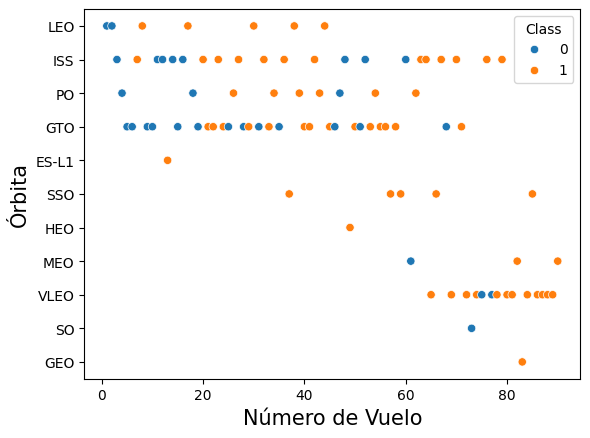

In [10]:
# Trace un gráfico de dispersión con el eje x como Número de Vuelo y el eje y como la Órbita, y hue como el valor de la clase[cite: 4]
sns.scatterplot(y="Orbit", x="FlightNumber", hue="Class", data=df)
plt.xlabel("Número de Vuelo",fontsize=15)
plt.ylabel("Órbita",fontsize=15)
plt.show()

Debería ver que en la órbita LEO el Éxito parece estar relacionado con el número de vuelos; por otro lado, no parece haber ninguna relación entre el número de vuelo cuando se está en órbita GTO.[cite: 4]


### TAREA  5: Visualizar la relación entre la Carga Útil y el tipo de Órbita[cite: 4]


Del mismo modo, podemos trazar gráficos de dispersión de Carga Útil vs. Órbita para revelar la relación entre la Carga Útil y el tipo de Órbita[cite: 4]


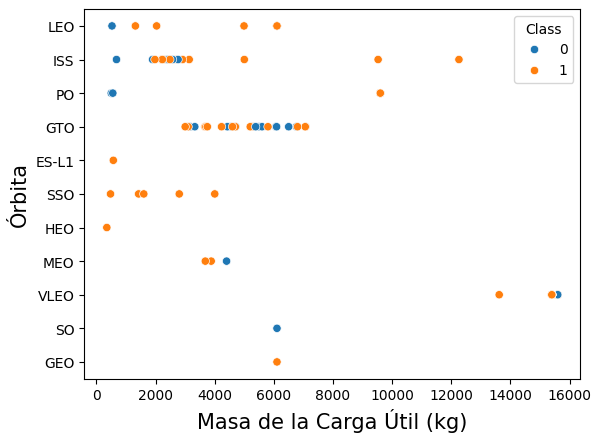

In [11]:
# Trace un gráfico de dispersión con el eje x como Carga Útil y el eje y como la Órbita, y hue como el valor de la clase[cite: 4]
sns.scatterplot(y="Orbit", x="PayloadMass", hue="Class", data=df)
plt.xlabel("Masa de la Carga Útil (kg)",fontsize=15)
plt.ylabel("Órbita",fontsize=15)
plt.show()

Con cargas útiles pesadas, los aterrizajes exitosos o la tasa de aterrizaje positivo son mayores para Polar, LEO e ISS.  [cite: 4]

Sin embargo, para GTO no podemos distinguir esto bien, ya que tanto la tasa de aterrizaje positivo como el aterrizaje negativo (misión fallida) están presentes aquí.[cite: 4]




### TAREA  6: Visualizar la tendencia anual del éxito de los lanzamientos[cite: 4]


Puede trazar un gráfico de líneas con el eje x como el <code>Year</code> y el eje y como la tasa de éxito promedio, para obtener la tendencia promedio del éxito de los lanzamientos. [cite: 4]


La función le ayudará a obtener el año a partir de la fecha:[cite: 4]


In [12]:
# Una función para extraer los años de la fecha [cite: 4]
year=[]
def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
    

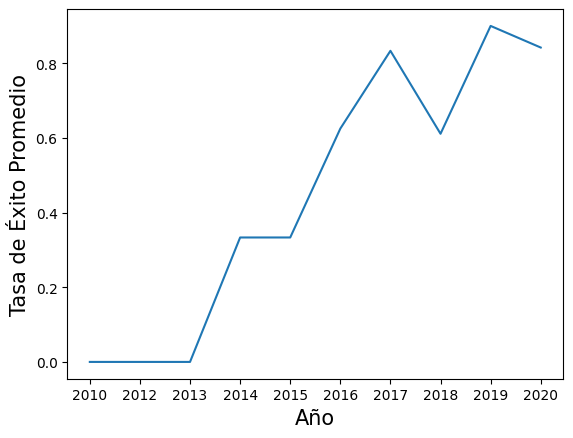

In [13]:
# Trace un gráfico de líneas con el eje x como el año extraído y el eje y como la tasa de éxito[cite: 4]
df['Year'] = Extract_year(df['Date'])
success_rate_year = df.groupby('Year')['Class'].mean().reset_index()

sns.lineplot(x="Year", y="Class", data=success_rate_year)
plt.xlabel("Año",fontsize=15)
plt.ylabel("Tasa de Éxito Promedio",fontsize=15)
plt.show()

Puede observar que la tasa de éxito desde 2013 se mantuvo aumentando hasta 2017 (estable en 2014) y después de 2015 comenzó a aumentar.[cite: 4]


## Ingeniería de Características [cite: 4]


A estas alturas, debería obtener algunas ideas preliminares sobre cómo cada variable importante afectaría la tasa de éxito, seleccionaremos las características que se utilizarán en la predicción del éxito en el módulo futuro.[cite: 4]


In [14]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


 ### TAREA  7: Crear variables ficticias (dummy variables) para columnas categóricas[cite: 4]


Use la función <code>get_dummies</code> y el dataframe <code>features</code> para aplicar OneHotEncoder a la columna <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code> y <code>Serial</code>. Asigne el valor a la variable <code>features_one_hot</code>, muestre los resultados usando el método head. Su dataframe resultante debe incluir todas las características, incluidas las codificadas.[cite: 4]


In [15]:
# PISTA: Use la función get_dummies() en las columnas categóricas[cite: 4]
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TAREA  8: Convertir todas las columnas numéricas a `float64`[cite: 4]


Ahora que nuestro dataframe <code>features_one_hot</code> solo contiene números, convierta todo el dataframe al tipo de variable <code>float64</code>[cite: 4]


In [16]:
# PISTA: use la función astype[cite: 4]
features_one_hot = features_one_hot.astype('float64')
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Ahora podemos exportarlo a un <b>CSV</b> para la siguiente sección, pero para que las respuestas sean consistentes, en el próximo laboratorio proporcionaremos datos en un rango de fechas preseleccionado. [cite: 4]


<code>features_one_hot.to_csv('dataset_part_3.csv', index=False)</code>


## Autores[cite: 4]


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> tiene un doctorado en Ingeniería Eléctrica, su investigación se centró en el uso del aprendizaje automático, procesamiento de señales y visión por computadora para determinar cómo los videos impactan la cognición humana. Joseph ha estado trabajando para IBM desde que completó su doctorado.[cite: 4]


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> es un Científico de Datos en IBM y cursa una Maestría en Gestión de la Inteligencia Artificial en la Universidad de Queen.[cite: 4]


## Registro de Cambios[cite: 4]


| Fecha (AAAA-MM-DD) | Versión | Cambiado Por | Descripción del Cambio      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-10-12        | 1.1     | Lakshmi Holla     | Markdown modificado |
| 2020-09-20        | 1.0     | Joseph     | Múltiples Áreas modificadas |
| 2020-11-10       | 1.1    | Nayef      | actualizando los datos de entrada |


Derechos de autor © 2020 IBM Corporation. Todos los derechos reservados.[cite: 4]
